<a href="https://colab.research.google.com/github/TribuneAlpha/2026_Spring_classes/blob/main/W4HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Data Cleaning
import pandas as pd

data1 = {
    'ID': [1, 2, 3, 4, 4, 5, 6, 6],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'David', 'Eve', 'Frank', 'Frank'],
    'Age': [25, 30, 35, 40, 40, 28, 50, 50]
}

df1 = pd.DataFrame(data1)
df1


,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
4,4,David,40
5,5,Eve,28
6,6,Frank,50
7,6,Frank,50


In [4]:
# Duplicate handling (keep first)

df_no_dupes = df1.drop_duplicates(keep='first')
df_no_dupes
#

,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
5,5,Eve,28
6,6,Frank,50


In [17]:
# handling missing data
data2 = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, None, 40, 28],
    'Salary': [50000, 60000, 55000, None, 58000]
}

df2 = pd.DataFrame(data2)
df2

,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
2,Charlie,NaN,55000.0
3,David,40.0,NaN
4,Eve,28.0,58000.0


In [9]:
# Missing val Row Deletion
df2_no_missing = df2.dropna()
print("Dataset after dropping rows with Nonetype values:")
df2_no_missing


Dataset after dropping rows with Nonetype values:


,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
4,Eve,28.0,58000.0


In [10]:
# Deleting columns with missing rows
df_column_drop =  df2.dropna(axis=1)
print("\nDataset after dropping columns with missing vals:")
df_column_drop


Dataset after dropping columns with missing vals:


,Name
0,Alice
1,Bob
2,Charlie
3,David
4,Eve


In [13]:
# Filling in missing data: 0
df_0 = df2.fillna(0)
df_0

,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
2,Charlie,0.0,55000.0
3,David,40.0,0.0
4,Eve,28.0,58000.0


In [35]:
# Filling in missing data: mean

mean_age = df2['Age'].mean()
mean_salary = df2['Salary'].mean()

print('\nMean Age: ', mean_age)
print('Mean Salary: ', mean_salary)

df_mean = df2.copy() # making a copy of the NaN dataframe to fill in

df_mean = df_mean.assign(
    Age = df_mean['Age'].fillna(mean_age),
    Salary = df_mean['Salary'].fillna(mean_salary)
)

print('new dataframe:')
print(df_mean)


Mean Age:  30.75
Mean Salary:  55750.0
new dataframe:
      Name    Age   Salary
0    Alice  25.00  50000.0
1      Bob  30.00  60000.0
2  Charlie  30.75  55000.0
3    David  40.00  55750.0
4      Eve  28.00  58000.0


In [23]:
data = {
    "Name": ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, None, 40, 28],
    'Salary': [50000, 60000, 55000, None, 58000],
    'City': ['New York', 'Los Angelos', None, 'Chicago', 'Houston']
}
df = pd.DataFrame(data)
df

,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angelos
2,Charlie,NaN,55000.0,None
3,David,40.0,NaN,Chicago
4,Eve,28.0,58000.0,Houston


In [26]:
# Filling in missing data: median
df_median = df.copy()

df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())
df_median['Salary'] = df_median['Salary'].fillna(df_median['Salary'].median())

# Mode verison for the Category Column
df_median['City'] = df_median['City'].fillna(df_median['City'].mode()[0])

print('\nDataset after Median and Mode Imputation:\n')
df_median


Dataset after Median and Mode Imputation:



,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angelos
2,Charlie,29.0,55000.0,Chicago
3,David,40.0,56500.0,Chicago
4,Eve,28.0,58000.0,Houston


In [34]:
# Filling in missing data: mode
df_mode = df.copy()

df_mode['Age'] = df_mode['Age'].fillna(df_mode['Age'].mode()[0])
df_mode['Salary'] = df_mode['Salary'].fillna(df_mode['Salary'].mode()[0])
df_mode['City'] = df_mode['City'].fillna(df_mode['City'].mode()[0])

print(df_mode)

      Name   Age   Salary         City
0    Alice  25.0  50000.0     New York
1      Bob  30.0  60000.0  Los Angelos
2  Charlie  25.0  55000.0      Chicago
3    David  40.0  50000.0      Chicago
4      Eve  28.0  58000.0      Houston


In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = np.array(
    list(zip(range(10,110,10), range(200,700,50)))
)
df = pd.DataFrame(data, columns=['Feature1', 'Feature2'])
print('Orginal Data:')
df

Orginal Data:


,Feature1,Feature2
0,10,200
1,20,250
2,30,300
3,40,350
4,50,400
5,60,450
6,70,500
7,80,550
8,90,600
9,100,650


In [47]:
#Normalization, Min/Max scaling:
scalar_minmax = MinMaxScaler()
mormalized_data = scalar_minmax.fit_transform(df)

df_normalized = pd.DataFrame(mormalized_data, columns = ['Feature1', 'Feature2'])

print('\nNormalized Data (Min-Max Scaling):\n')
df_normalized


Normalized Data (Min-Max Scaling):



,Feature1,Feature2
0,0.000000,0.000000
1,0.111111,0.111111
2,0.222222,0.222222
3,0.333333,0.333333
4,0.444444,0.444444
5,0.555556,0.555556
6,0.666667,0.666667
7,0.777778,0.777778
8,0.888889,0.888889
9,1.000000,1.000000


In [48]:
scaler_standard = StandardScaler()

standardized_data = scaler_standard.fit_transform(df)

df_standardized = pd.DataFrame(standardized_data, columns = ['Feature1', 'Feature2'])

print('Standardized Data (Z-score Scaling):')
df_standardized

Standardized Data (Z-score Scaling):


,Feature1,Feature2
0,-1.566699,-1.566699
1,-1.218544,-1.218544
2,-0.870388,-0.870388
3,-0.522233,-0.522233
4,-0.174078,-0.174078
5,0.174078,0.174078
6,0.522233,0.522233
7,0.870388,0.870388
8,1.218544,1.218544
9,1.566699,1.566699


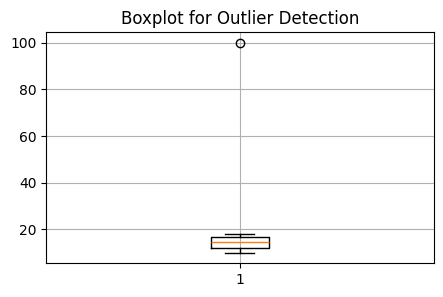

In [50]:
# Graphical Outlyer detection:
import matplotlib.pyplot as plt

data = np.array([10, 12, 12, 13, 14, 15, 16, 17, 18, 100])

figure = plt.figure(figsize=(5,3))
plt.boxplot(data)
plt.title("Boxplot for Outlier Detection")
plt.grid(True)
plt.show()

In [51]:
# Z-scaling detection
from scipy import stats

z_scores = stats.zscore(data)

threshold = 2.5

outliers = np.where(np.abs(z_scores) > threshold)

print("Z-scores:", z_scores)
print("")
print("Outlier indicies:", outliers)
print("")
print("Outlier values:", data[outliers])

Z-scores: [-0.49085998 -0.41355919 -0.41355919 -0.3749088  -0.33625841 -0.29760802
 -0.25895763 -0.22030723 -0.18165684  2.9876753 ]

Outlier indicies: (array([9]),)

Outlier values: [100]


In [53]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

data = ['Red', 'Green', 'Blue', 'Red', 'Green']

label_encoder = LabelEncoder()

encoded_data = label_encoder.fit_transform(data)

print(encoded_data)

[2 1 0 2 1]


In [56]:
# One-Hot Encoding
df = pd.DataFrame(data, columns=['Color'])

one_hot_encoded = pd.get_dummies(df['Color'], dtype=int)

print("One-Hot Encoded Data:")
print(one_hot_encoded)

One-Hot Encoded Data:
   Blue  Green  Red
0     0      0    1
1     0      1    0
2     1      0    0
3     0      0    1
4     0      1    0
